A example Variance reduction simulation using FW Cadis and Random Ray

The example makes a normal model,
then calls a function that generates the weight windows (using FW Cadis and Random Ray)
then performs the simulation using the weight windows

In [1]:
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm  # used for plotting log scale graphs

import openmc
from pathlib import Path

# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config["cross_sections"] = Path.home() / "nuclear_data" / "cross_sections.xml"

In [2]:
mat_air = openmc.Material(name="air")
mat_air.add_element("N", 0.784431)
mat_air.add_element("O", 0.210748)
mat_air.add_element("Ar", 0.0046)
mat_air.set_density("g/cc", 0.001205)

mat_concrete = openmc.Material(name="concrete")
mat_concrete.add_element("H", 0.168759)
mat_concrete.add_element("C", 0.001416)
mat_concrete.add_element("O", 0.562524)
mat_concrete.add_element("Na", 0.011838)
mat_concrete.add_element("Mg", 0.0014)
mat_concrete.add_element("Al", 0.021354)
mat_concrete.add_element("Si", 0.204115)
mat_concrete.add_element("K", 0.005656)
mat_concrete.add_element("Ca", 0.018674)
mat_concrete.add_element("Fe", 0.00426)
mat_concrete.set_density("g/cm3", 2.3)

materials = openmc.Materials([mat_air, mat_concrete])

In [3]:
width_a = 100
width_b = 100
width_c = 500
width_d = 100
width_e = 100
width_f = 100
width_g = 100

depth_a = 100
depth_b = 100
depth_c = 700
depth_d = 600
depth_e = 100
depth_f = 100

height_j = 100
height_k = 300
height_l = 100

xplane_0 = openmc.XPlane(x0=0, boundary_type="vacuum")
xplane_1 = openmc.XPlane(x0=xplane_0.x0 + width_a)
xplane_2 = openmc.XPlane(x0=xplane_1.x0 + width_b)
xplane_3 = openmc.XPlane(x0=xplane_2.x0 + width_c)
xplane_4 = openmc.XPlane(x0=xplane_3.x0 + width_d)
xplane_5 = openmc.XPlane(x0=xplane_4.x0 + width_e)
xplane_6 = openmc.XPlane(x0=xplane_5.x0 + width_f)
xplane_7 = openmc.XPlane(x0=xplane_6.x0 + width_g, boundary_type="vacuum")

yplane_0 = openmc.YPlane(y0=0, boundary_type="vacuum")
yplane_1 = openmc.YPlane(y0=yplane_0.y0 + depth_a)
yplane_2 = openmc.YPlane(y0=yplane_1.y0 + depth_b)
yplane_3 = openmc.YPlane(y0=yplane_2.y0 + depth_c)
yplane_4 = openmc.YPlane(y0=yplane_3.y0 + depth_d)
yplane_5 = openmc.YPlane(y0=yplane_4.y0 + depth_e)
yplane_6 = openmc.YPlane(y0=yplane_5.y0 + depth_f, boundary_type="vacuum")

zplane_1 = openmc.ZPlane(z0=0, boundary_type="vacuum")
zplane_2 = openmc.ZPlane(z0=zplane_1.z0 + height_j)
zplane_3 = openmc.ZPlane(z0=zplane_2.z0 + height_k)
zplane_4 = openmc.ZPlane(z0=zplane_3.z0 + height_l, boundary_type="vacuum")

outside_left_region = (
    +xplane_0 & -xplane_1 & +yplane_1 & -yplane_5 & +zplane_1 & -zplane_4
)
wall_left_region = +xplane_1 & -xplane_2 & +yplane_2 & -yplane_4 & +zplane_2 & -zplane_3
wall_right_region = (
    +xplane_5 & -xplane_6 & +yplane_2 & -yplane_5 & +zplane_2 & -zplane_3
)
wall_top_region = +xplane_1 & -xplane_4 & +yplane_4 & -yplane_5 & +zplane_2 & -zplane_3
outside_top_region = (
    +xplane_0 & -xplane_7 & +yplane_5 & -yplane_6 & +zplane_1 & -zplane_4
)
wall_bottom_region = (
    +xplane_1 & -xplane_6 & +yplane_1 & -yplane_2 & +zplane_2 & -zplane_3
)
outside_bottom_region = (
    +xplane_0 & -xplane_7 & +yplane_0 & -yplane_1 & +zplane_1 & -zplane_4
)
wall_middle_region = (
    +xplane_3 & -xplane_4 & +yplane_3 & -yplane_4 & +zplane_2 & -zplane_3
)
outside_right_region = (
    +xplane_6 & -xplane_7 & +yplane_1 & -yplane_5 & +zplane_1 & -zplane_4
)

room_region = +xplane_2 & -xplane_3 & +yplane_2 & -yplane_4 & +zplane_2 & -zplane_3
gap_region = +xplane_3 & -xplane_4 & +yplane_2 & -yplane_3 & +zplane_2 & -zplane_3
corridor_region = +xplane_4 & -xplane_5 & +yplane_2 & -yplane_5 & +zplane_2 & -zplane_3

roof_region = +xplane_1 & -xplane_6 & +yplane_1 & -yplane_5 & +zplane_1 & -zplane_2
floor_region = +xplane_1 & -xplane_6 & +yplane_1 & -yplane_5 & +zplane_3 & -zplane_4

outside_left_cell = openmc.Cell(region=outside_left_region, fill=mat_air)
outside_right_cell = openmc.Cell(region=outside_right_region, fill=mat_air)
outside_top_cell = openmc.Cell(region=outside_top_region, fill=mat_air)
outside_bottom_cell = openmc.Cell(region=outside_bottom_region, fill=mat_air)
wall_left_cell = openmc.Cell(region=wall_left_region, fill=mat_concrete)
wall_right_cell = openmc.Cell(region=wall_right_region, fill=mat_concrete)
wall_top_cell = openmc.Cell(region=wall_top_region, fill=mat_concrete)
wall_bottom_cell = openmc.Cell(region=wall_bottom_region, fill=mat_concrete)
wall_middle_cell = openmc.Cell(region=wall_middle_region, fill=mat_concrete)
room_cell = openmc.Cell(region=room_region, fill=mat_air)
gap_cell = openmc.Cell(region=gap_region, fill=mat_air)
corridor_cell = openmc.Cell(region=corridor_region, fill=mat_air)

roof_cell = openmc.Cell(region=roof_region, fill=mat_concrete)
floor_cell = openmc.Cell(region=floor_region, fill=mat_concrete)

geometry = openmc.Geometry(
    [
        outside_bottom_cell,
        outside_top_cell,
        outside_left_cell,
        outside_right_cell,
        wall_left_cell,
        wall_right_cell,
        wall_top_cell,
        wall_bottom_cell,
        wall_middle_cell,
        room_cell,
        gap_cell,
        corridor_cell,
        roof_cell,
        floor_cell,
    ]
)

In [4]:
# location of the point source
source_x = width_a + width_b + width_c * 0.5
source_y = depth_a + depth_b + depth_c * 0.75
source_z = height_j + height_k * 0.5
space = openmc.stats.Point((source_x, source_y, source_z))

# all (100%) of source particles are 2.5MeV energy
source = openmc.IndependentSource(
    space=space,
    angle=openmc.stats.Isotropic(),
    energy=openmc.stats.Discrete([2.5e6], [1.0]),
    particle="neutron",
)


In [5]:
settings = openmc.Settings()
settings.run_mode = "fixed source"
settings.source = [source, source]

model = openmc.Model(geometry, materials, settings)

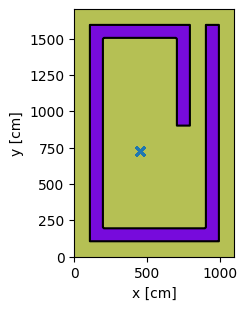

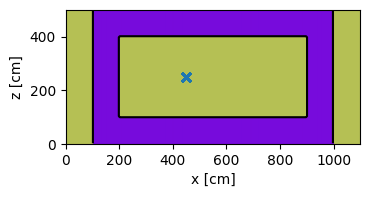

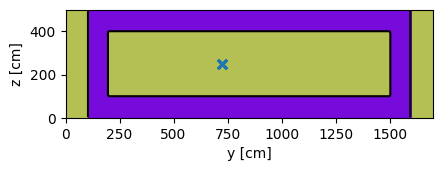

In [6]:
plot = model.plot(basis="xy", color_by="material", n_samples=10000, outline=True)
plot.figure.savefig("geometry_xy.png", bbox_inches="tight")
plot = model.plot(
    basis="xz", color_by="material", n_samples=10000, outline=True, plane_tolerance=150,
)
plot.figure.savefig("geometry_xz.png", bbox_inches="tight")
plot = model.plot(
    basis="yz", color_by="material", n_samples=10000, outline=True, plane_tolerance=150
)
plot.figure.savefig("geometry_yz.png", bbox_inches="tight")

In [7]:
!rm *.xml

from typing import Tuple


# TODO this has no measure of how effective the various settings are, user can
# easily set the number of particles and batches to be too low or too high
# ideally these settings would be automated for the user
def generate_ww(
    model: openmc.Model,
    random_ray_particles: int = 800,
    random_ray_batches: int = 100,
    random_ray_inactive: int = 50,
    weight_window_generator_max_realizations: int = 100,
    multigroup_nparticles: int = 2000,
    mesh_dimension: Tuple[int] | int = 1000000,
    particle_type: str = "neutron",
):
    """A function to generate a weight window for a given OpenMC model using
    FW-Cadis and Random Ray.

    Args:
        model (openmc.Model): The OpenMC model to generate the weight window for.
        random_ray_particles (int): Number of particles per batch for Random Ray.
        random_ray_batches (int): Number of batches for Random Ray.
        random_ray_inactive (int): Number of inactive batches for Random Ray.
        weight_window_generator_max_realizations (int): Maximum number of realizations for the weight window
            generator.
        multigroup_nparticles (int): Number of particles for the multigroup cross section generation.
        mesh_dimension (Tuple[int]): Dimensions of the regular mesh used for the weight window generation.
        particle_type (str): Type of particle for the weight window (e.g., 'neutron', 'photon').

    Returns:
        openmc.WeightWindow: The generated weight window object.
    """

    import copy

    rr_model = copy.deepcopy(model)

    rr_model.tallies = openmc.Tallies()  # removing any tallies
    rr_model.plots = openmc.Plots()  # removing any plotting
    # disabling photon transport as it is not supported in multigroup transport
    rr_model.settings.photon_transport = False

    # applying user specified batches and particles to model
    rr_model.settings.batches = random_ray_batches
    rr_model.settings.particles = random_ray_particles

    # Normally in fixed source problems we don't use inactivie batches.
    # However when using Random Ray we do need to use inactive batches
    # More info here https://docs.openmc.org/en/stable/usersguide/random_ray.html#batches
    rr_model.settings.inactive = random_ray_inactive

    # this produces a mgxs.h5 file that we make use of
    rr_model.convert_to_multigroup(
        method="stochastic_slab",  # most robust option
        overwrite_mgxs_library=True,  # overrights the any existing mgxs file
        nparticles=multigroup_nparticles,  # this is the default but can be adjusted upward to improve the fidelity of the generated cross section library
        groups="CASMO-2"  # this is the default but can be changed to any other group structure
    )

    rr_model.convert_to_random_ray()

    mesh = openmc.RegularMesh().from_domain(rr_model)
    if isinstance(mesh_dimension, int):
        import openmc.checkvalue as cv

        cv.check_greater_than("mesh_dimension", mesh_dimension, 1, equality=True)
        # If a single integer is provided, divide the domain into that many
        # mesh cells with roughly equal lengths in each direction
        ideal_cube_volume = model.bounding_box.volume / mesh_dimension
        ideal_cube_size = ideal_cube_volume ** (1 / 3)
        mesh_dimension = tuple(
            max(1, int(round(side / ideal_cube_size)))
            for side in model.bounding_box.width
        )

    mesh.dimension = mesh_dimension
    mesh.id = 1

    # avoid writing files we don't make use of
    rr_model.settings.output = {"summary": False, "tallies": False}

    # Subdivide random ray source regions
    rr_model.settings.random_ray["source_region_meshes"] = [
        (mesh, [rr_model.geometry.root_universe])
    ]

    # less likely to get negative values in the weight window
    rr_model.settings.random_ray["volume_estimator"] = "naive"

    # Add a weight window generator to the model
    rr_model.settings.weight_window_generators = openmc.WeightWindowGenerator(
        method="fw_cadis",
        mesh=mesh,
        max_realizations=weight_window_generator_max_realizations,
        particle_type=particle_type,  # TODO should this particle_type be checked against the model.settings.source.particle?
        energy_bounds=[0.0, 100e6]
        # energy_bounds=openmc.mgxs.EnergyGroups("CASMO-2").group_edges
    )

    # this generates a statepoint file but more importantly it also makes a weight_windows.h5 file
    rr_model.run()

    # loads in the weight window file to a weight window object
    weight_windows = openmc.WeightWindowsList().from_hdf5("weight_windows.h5")
    # weight_windows = openmc.hdf5_to_wws("weight_windows.h5")

    # as we only generate a single weight window we can return the first entry in the list
    weight_window = weight_windows[0]

    return weight_window

In [8]:
weight_window = generate_ww(model=model)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=40.
  warn(msg, IDWarning)
/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=2.
  warn(msg, IDWarning)
/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=11.
  warn(msg, IDWarning)


 Reading N15 from /home/jon/nuclear_data/neutron/N15.h5
 Reading O16 from /home/jon/nuclear_data/neutron/O16.h5
 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5
 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5
 Reading Ar36 from /home/jon/nuclear_data/neutron/Ar36.h5
 Reading Ar38 from /home/jon/nuclear_data/neutron/Ar38.h5
 Reading Ar40 from /home/jon/nuclear_data/neutron/Ar40.h5
 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Reading C12 from /home/jon/nuclear_data/neutron/C12.h5
 Reading C13 from /home/jon/nuclear_data/neutron/C13.h5
 Reading Na23 from /home/jon/nuclear_data/neutron/Na23.h5
 Reading Mg24 from /home/jon/nuclear_data/neutron/Mg24.h5
 Reading Mg25 from /home/jon/nuclear_data/neutron/Mg25.h5
 Reading Mg26 from /home/jon/nuclear_data/neutron/Mg26.h5
 Reading Al27 from /home/jon/nuclear_data/neutron/Al27.h5
 Reading Si28 from /home/jon/nuclear_data/neutron/Si28.h5
 Reading Si29 from /home/jon/nucle

/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)


In [9]:
!ls -lh *.h5

-rw-rw-r-- 1 jon jon 16K Jun 26 18:13 mgxs.h5
-rw-rw-r-- 1 jon jon 16M Jun 26 18:15 statepoint.100.h5
-rw-rw-r-- 1 jon jon 16M Jun 25 18:18 statepoint.12.h5
-rw-rw-r-- 1 jon jon 16M Jun 26 17:56 statepoint.200.h5
-rw-rw-r-- 1 jon jon 98K Jun 25 18:17 summary.h5
-rw-rw-r-- 1 jon jon 16M Jun 26 18:15 weight_windows.h5


In [10]:
print(f"mesh shape is {weight_window.lower_ww_bounds.shape}")

mid_z_index = int(weight_window.lower_ww_bounds.shape[2] / 2)

ww_slice = weight_window.lower_ww_bounds.squeeze()[
    :, :, mid_z_index
].T  # Slicing the weight window in the middle z plane

ww_slice

mesh shape is (112, 174, 51, 1)


array([[1.54528166e-05, 2.01918006e-05, 1.66010183e-05, ...,
        2.32231058e-05, 2.29584128e-05, 2.34487544e-05],
       [1.68270682e-05, 1.77494332e-05, 1.70241690e-05, ...,
        1.87521625e-05, 2.18964185e-05, 1.48446214e-05],
       [1.60404038e-05, 1.70577991e-05, 1.36130056e-05, ...,
        2.13800424e-05, 1.88602216e-05, 2.26999889e-05],
       ...,
       [9.62199796e-06, 7.54120009e-06, 8.14377730e-06, ...,
        4.26689746e-06, 6.67675080e-06, 4.69786286e-06],
       [8.97517732e-06, 6.71144403e-06, 8.18615544e-06, ...,
        3.88126926e-06, 5.67015621e-06, 5.65570757e-06],
       [5.85720637e-06, 6.39462126e-06, 8.25104501e-06, ...,
        4.53469881e-06, 6.06010981e-06, 4.81124973e-06]], shape=(174, 112))

Text(0.5, 1.0, 'lower_ww_bounds')

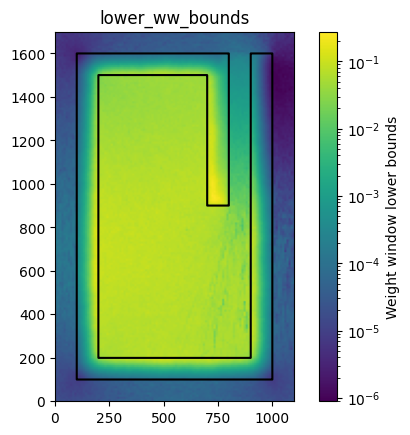

In [11]:
ax1 = plt.subplot()

im = ax1.imshow(
    ww_slice, origin="lower", extent=model.bounding_box.extent["xy"], norm=LogNorm()
)

cbar = ax1.figure.colorbar(im, ax=ax1)
cbar.set_label("Weight window lower bounds")

ax1 = model.plot(
    outline="only",
    extent=model.bounding_box.extent["xz"],
    axes=ax1,  # Use the same axis as ax1\n",
    pixels=10_000_000,  # avoids rounded corners on outline
    color_by="material",
)
ax1.set_title("lower_ww_bounds")

In [12]:
settings = openmc.Settings()
settings.run_mode = "fixed source"
settings.source = source
settings.particles = 40000
settings.batches = 6
settings.run_mode = "fixed source"

settings.weight_windows_on = True
settings.weight_window_checkpoints = {"collision": True, "surface": True}
settings.survival_biasing = False
settings.weight_windows = weight_window

In [13]:
# Make a flux tally for viewing the results of the simulation


# for some reason if the mesh gets replaced with the mesh that the weight window was generated with
# so one must use the same mesh for tallies as was used for the weight window generation
mesh = openmc.RegularMesh().from_domain(model)
mesh.dimension = (100, 100, 1)  # one slice in the z direction to make plotting easy
mesh.id = 1

mesh_filter = openmc.MeshFilter(mesh)
# mesh_filter = openmc.MeshFilter(weight_window.mesh) this works but I would rather have a new mesh

flux_tally = openmc.Tally(name="flux tally")
flux_tally.filters = [mesh_filter]
flux_tally.scores = ["flux"]
tallies = openmc.Tallies([flux_tally])

/home/jon/openmc/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)


In [14]:
model = openmc.Model(geometry, materials, settings, tallies)

In [15]:
def run_and_plot(model: openmc.Model, image_filename: str) -> openmc.StatePoint:

    !rm s*.h5 || true
    !rm s*.xml || true
    sp_filename = model.run()

    with openmc.StatePoint(sp_filename) as sp:
        flux_tally = sp.get_tally(name="flux tally")

    mesh = flux_tally.find_filter(openmc.MeshFilter).mesh
    mesh_extent = mesh.bounding_box.extent["xy"]
    mid_z_index = int(mesh.dimension[2] / 2)
    print(f"mesh shape is {mesh.dimension}, mid_z_index is {mid_z_index}")

    # create a plot of the mean flux values
    flux_mean = flux_tally.get_reshaped_data(value="mean", expand_dims=True).squeeze()

    # Slicing the flux mean in the middle z plane
    flux_mean_slice = flux_mean.squeeze()[:, :, mid_z_index].T

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
    ax1.imshow(
        flux_mean_slice,
        origin="lower",
        extent=mesh_extent,
        norm=LogNorm(),
    )

    ax1 = model.plot(
        outline="only",
        extent=model.bounding_box.extent["xz"],
        axes=ax1,  # Use the same axis as ax1\n",
        pixels=10_000_000,  # avoids rounded corners on outline
        color_by="material",
    )
    ax1.set_title("Flux Mean")

    # create a plot of the flux relative error
    flux_std_dev = flux_tally.get_reshaped_data(
        value="std_dev", expand_dims=True
    ).squeeze()

    flux_std_dev_slice = flux_std_dev.squeeze()[
        :, :, mid_z_index
    ].T  # Slicing the flux mean in the middle z plane

    ax2.imshow(
        flux_std_dev_slice,
        origin="lower",
        extent=mesh_extent,
        norm=LogNorm(),
    )

    ax2 = model.plot(
        outline="only",
        extent=model.bounding_box.extent["xz"],
        axes=ax2,  # Use the same axis as ax2\n",
        pixels=10_000_000,  # avoids rounded corners on outline
        color_by="material",
    )
    ax2.set_title("Flux Std. Dev.")

    plt.savefig(image_filename)
    return sp

rm: cannot remove 's*.xml': No such file or directory
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%

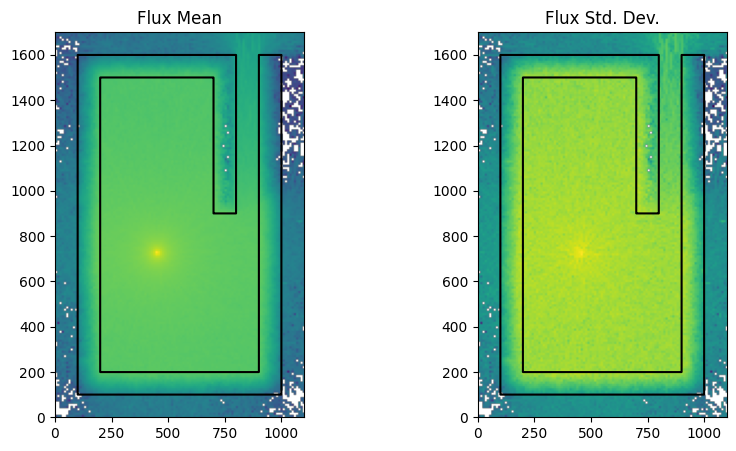

In [16]:
run_and_plot(model, "flux_results_with_ww.png")

rm: cannot remove 's*.xml': No such file or directory
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%

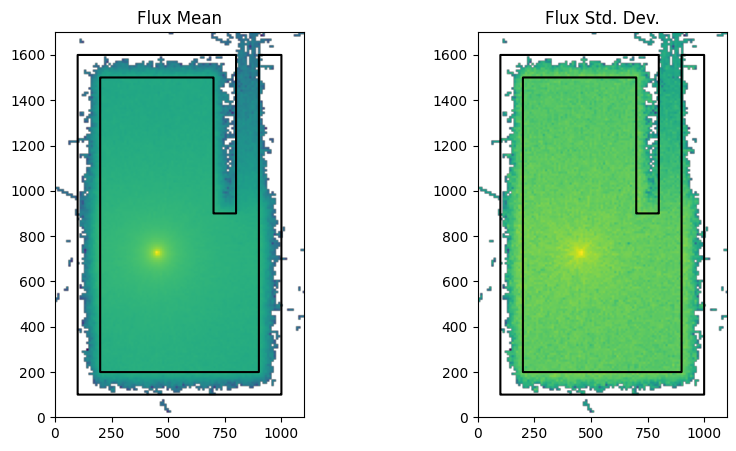

In [17]:
model.settings.weight_windows_on = False
model.settings.batches = 12

run_and_plot(model, "flux_results_with_ww.png")

In [18]:
mesh.dimension

(100, 100, 1)

In [19]:
mesh.width


[np.float64(11.0), np.float64(17.0), np.float64(500.0)]

In [20]:
for d, w in zip(weight_window.mesh.dimension, weight_window.mesh.width):
    print(w,d,w/d)

9.821428571428571 112 0.08769132653061225
9.770114942528735 174 0.056150085876601925
9.803921568627452 51 0.1922337562475971
